# Reproducing a Core Single-Cell RNA-Seq Analysis Pipeline Using Scanpy

This notebook reproduces a **complete single-cell RNA-seq (scRNA-seq)** data analysis pipeline using the Python package **Scanpy**.  

The steps covered in the notebook include:
1. Loading and preprocessing data  
2. Quality control (QC)  
3. Normalization and feature selection  
4. Dimensionality reduction (PCA, UMAP)  
5. Clustering  
6. Marker gene detection and visualization
7. Biological interpretation of results

### Installation

In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.2 MB/s eta 0:00:00


In [ ]:
!pip install anndata

In [ ]:
!pip3 install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 28.6 MB/s eta 0:00:00


In [ ]:
!pip install celltypist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.4 MB/s eta 0:00:00


In [ ]:
!pip install decoupler

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.9/120.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.6 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=067154be9ead8819a7ba7ccb4e0bd59ab7714c03440e81693936be11165f6fd7
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
!pip install fa2-modified

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.8/620.8 kB 10.4 MB/s eta 0:00:00


### Loading Data
In this step, the single-cell expression matrix was loaded into an **AnnData** object (the core data structure in Scanpy), which contains:
- `adata.X`: the expression matrix (cells × genes)
- `adata.obs`: metadata for each cell
- `adata.var`: metadata for each gene


In [ ]:
#Import core single cell tools

import scanpy as sc
import anndata as ad

In [ ]:
!wget https://github.com/josoga2/sc/raw/refs/heads/main/bone_marrow.h5ad

--2025-12-08 18:05:26--  https://github.com/josoga2/sc/raw/refs/heads/main/bone_marrow.h5ad
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad [following]
--2025-12-08 18:05:27--  https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 354509549 (338M) [application/octet-stream]
Saving to: ‘bone_marrow.h5ad’

bone_marrow.h5ad    100%[===================>] 338.09M  24.0MB/s    in 16s     

2025-12-08 18:05:43 (20.9 MB/s) - ‘bone_marrow.h5ad’ saved [354509549/354

In [ ]:
bone_marrow_adata = sc.read_h5ad('bone_marrow.h5ad')

In [ ]:
print(bone_marrow_adata)

AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


In [ ]:
# Print the dimensions of our dataset
bone_marrow_adata.shape

(14783, 17374)

In [ ]:
#Meaning the dataset contains:
#14783 cells
#17374 genes

In [ ]:
# View the first 5 rows describing the genes in the dataset
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding


In [ ]:
# Also view the first 5 rows describing the cells (ID) in the dataset
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,is_primary_data,suspension_type,tissue_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,2P)e%zgsv_
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,78-year-old stage,Lv&N1yD6*0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,DZ>`^5OH2o
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,J4$QmqEgvX
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,False,cell,tissue,10x 3' v2,COVID-19,male,blood,unknown,39-year-old stage,Y&7u#&E`-T


In [ ]:
# View the dataset in a proper dataframe format

bone_marrow_adata.to_df()

,ENSG00000161920,ENSG00000122335,ENSG00000175548,ENSG00000100330,ENSG00000176340,ENSG00000179846,ENSG00000204860,ENSG00000172260,ENSG00000141424,ENSG00000164512,...,ENSG00000164114,ENSG00000151702,ENSG00000224578,ENSG00000138756,ENSG00000111052,ENSG00000176946,ENSG00000150456,ENSG00000284934,ENSG00000261842,ENSG00000260456
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.0,0.000000,0.0,0.0,9.436466,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,8.817776,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,0.0,8.651494,0.0,0.0,8.651494,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,0.0,0.000000,0.0,0.0,8.858533,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guo-TTTGTCAGTTTCGCTC-4,0.0,0.000000,0.0,0.0,8.389465,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGAGACG-7,0.0,0.000000,0.0,0.0,9.931639,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-TTTGTCATCAGATAAG-4,0.0,0.000000,0.0,0.0,10.009642,0.0,0.0,0.0,0.000000,0.0,...,0.0,9.01104,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Quality Control (QC)
Ideally, QC ensures we only keep high-quality cells and informative genes, and typical filters remove:
- Harmonize unique gene names (avoid gene duplications from old pipelines)
- Cells with too few genes (likely dead)
- Cells with too many genes (possible doublets)
- Genes expressed in very few cells (uninformative)

In [ ]:
# Following a useful step for older datasets,just in case of necessity.
bone_marrow_adata.var_names_make_unique()
bone_marrow_adata.obs_names_make_unique()

In [ ]:
# Checking for possible contamination from dying cells, ribosomal transcripts or haemoglobin

# As a rule of thumb:
# Cells with a high proportion of mitochondrial reads (say >10–20%) are likely stressed, apoptotic, or poorly captured.
# Ribosomal transcripts are removed because they represent global transcriptional activity, not cell-type-specific biology.
# Instead of true cell populations, high HB signal often represents ambient RNA contamination from lysed red blood cells.

bone_marrow_adata.var['MT'] = bone_marrow_adata.var_names.str.startswith("MT-")
bone_marrow_adata.var['RIBO'] = bone_marrow_adata.var_names.str.startswith("RPS", "RPL")
bone_marrow_adata.var['HB'] = bone_marrow_adata.var_names.str.startswith("^HB[^(P)]")

In [ ]:
# Now a quick check.

mt_genes = bone_marrow_adata.var[bone_marrow_adata.var['MT']]
mt_genes

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB


In [ ]:
ribo_genes = bone_marrow_adata.var[bone_marrow_adata.var['RIBO']]
ribo_genes

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB


In [ ]:
hb_genes = bone_marrow_adata.var[bone_marrow_adata.var['HB']]
hb_genes

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB


In [ ]:
# The quick check above showed there were no mitochondrial, ribosomal, or haemoglobin genes.
# Few more QC steps to ascertain this outcome:

# calculate the qc metrics

sc.pp.calculate_qc_metrics(
    bone_marrow_adata, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

In [ ]:
# Note that it is also included in the headers of obs

bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,total_counts_RIBO,log1p_total_counts_RIBO,pct_counts_RIBO,total_counts_HB,log1p_total_counts_HB,pct_counts_HB
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,40.537370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,57.850376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,59.749640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,56.156243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,100.000121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# And the gene list
bone_marrow_adata.var.head()


,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding,False,False,False,885,0.502831,0.407351,94.013394,7433.353516,8.913867
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding,False,False,False,405,0.231814,0.208488,97.260367,3426.911377,8.139707
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding,False,False,False,142,0.082084,0.078889,99.039437,1213.443970,7.102042
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding,False,False,False,404,0.227307,0.204822,97.267131,3360.278564,8.120077
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding,False,False,False,6898,4.277597,1.663471,53.338294,63235.750000,11.054641


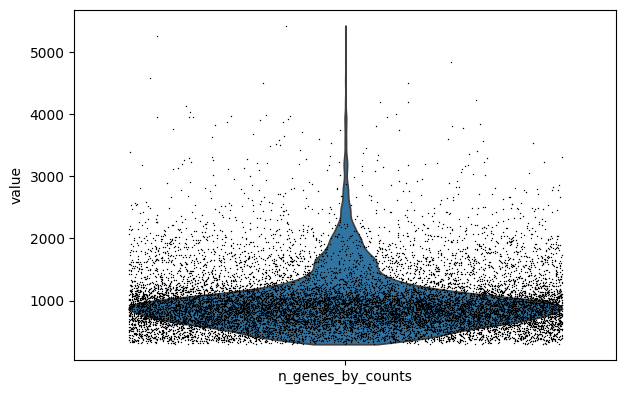

In [ ]:
# Average number of genes that have at least one detected identifier in each cell i.e., the number of genes expressed in each cell:

sc.pl.violin(
    bone_marrow_adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=False,
)

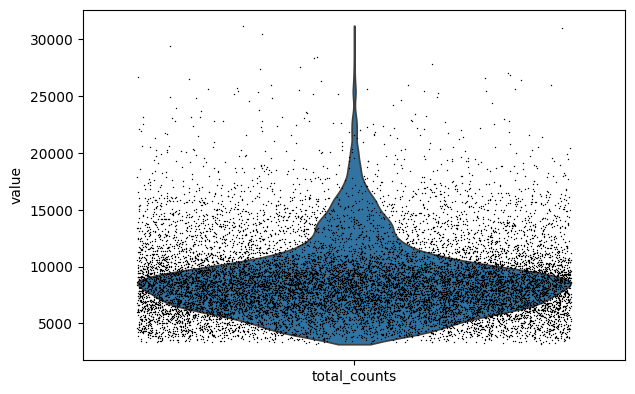

In [ ]:
# And the total number of molecules (UMI) detected in a cell:

sc.pl.violin(
    bone_marrow_adata,
    ["total_counts"],
    jitter=0.4,
    multi_panel=False,
)

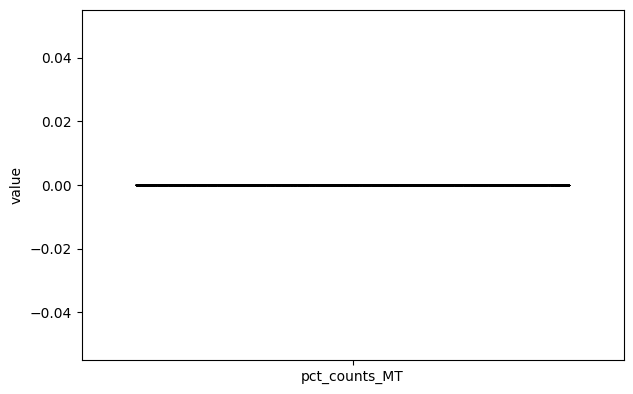

In [ ]:
# Are any mitochondrial genes present?
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_MT"],
    jitter=0.4,
    multi_panel=False,
)

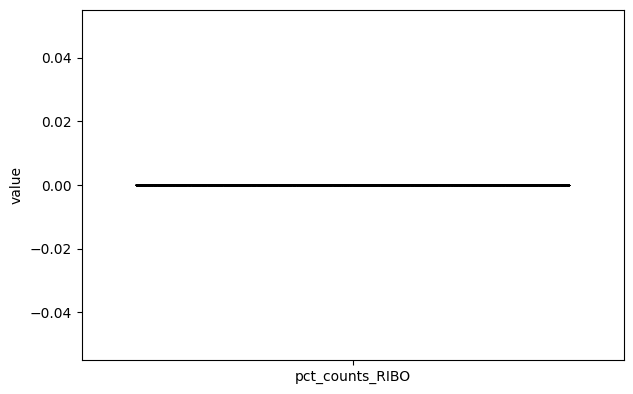

In [ ]:
# What about the ribosomal genes?
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_RIBO"],
    jitter=0.4,
    multi_panel=False,
)

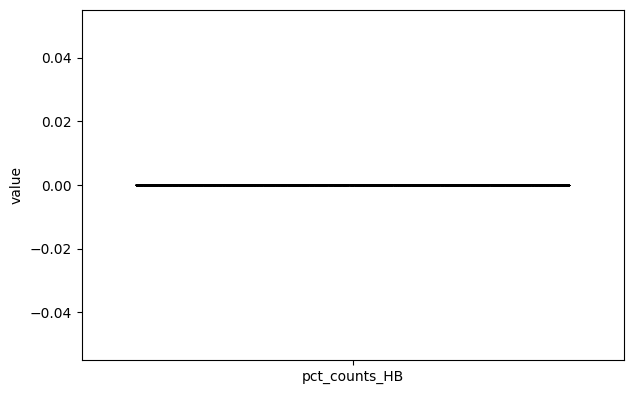

In [ ]:
# And the haemoglobin genes?
sc.pl.violin(
    bone_marrow_adata,
    ["pct_counts_HB"],
    jitter=0.4,
    multi_panel=False,
)

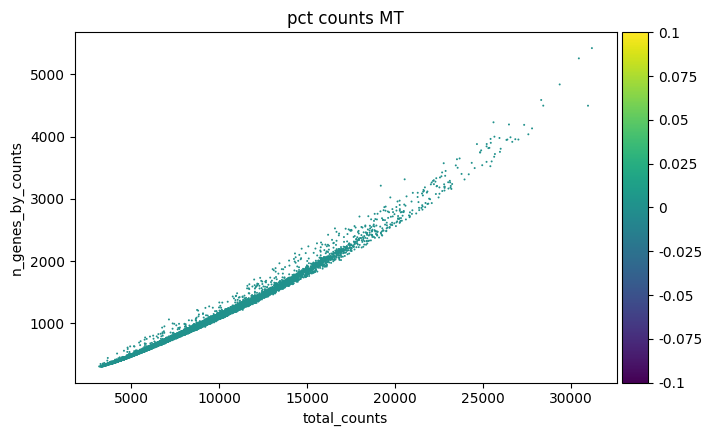

In [ ]:
# Visualise each of them in scatter plots.
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_MT")

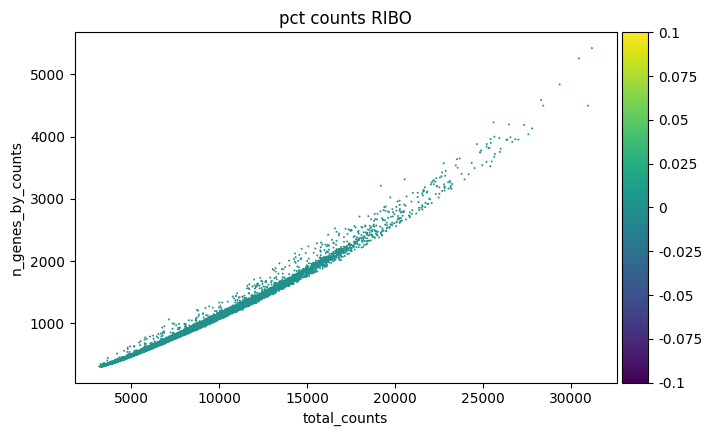

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_RIBO")

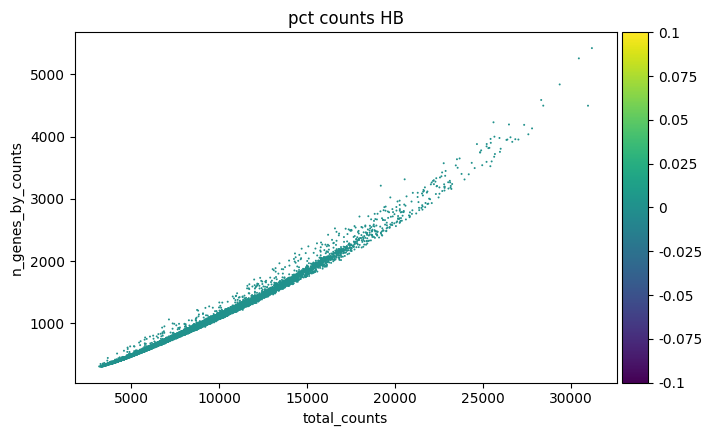

In [ ]:
sc.pl.scatter(bone_marrow_adata, "total_counts", "n_genes_by_counts", color="pct_counts_HB")

In [ ]:
# All the steps above confirmed there no MT, RIBO, and HB genes in the dataset.

In [ ]:
sc.pp.calculate_qc_metrics(bone_marrow_adata, inplace=True, log1p=True)

In [ ]:
bone_marrow_adata.obs.head()

,disease stage,treatment,timepoint,Dataset,sample,disease_original,disease_general,COVID-19 Condition,Lineage,Cell.group,...,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,total_counts_RIBO,log1p_total_counts_RIBO,pct_counts_RIBO,total_counts_HB,log1p_total_counts_HB,pct_counts_HB
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep2,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Myeloid,CD14+ Monocyte,...,40.537370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGAGGTTGC-7,remission,400 mg Tocilizumab at day 1,day 7,Guo et al._Nature Communication,Guo_P2-day7,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD8+ T cell,...,57.850376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGATACACA-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,59.749640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGCGATTCT-1,severe,400 mg Tocilizumab at day 1,day 1,Guo et al._Nature Communication,Guo_P1-day1-rep1,COVID-19 Severe,COVID-19 Severe/Late stage/Vent,severe,Lymphoid_T/NK,CD8+ T cell,...,56.156243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Guo-AAACCTGAGTGAAGAG-3,remission,400 mg Tocilizumab at day 1,day 5,Guo et al._Nature Communication,Guo_P1-day5-rep1,COVID-19 Mild/Remission,COVID-19 Remission,remission,Lymphoid_T/NK,CD4+ T cell,...,100.000121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
bone_marrow_adata.var.head()

,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,MT,RIBO,HB,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000161920,927,False,MED11,NCBITaxon:9606,gene,754,protein_coding,False,False,False,885,0.502831,0.407351,94.013394,7433.353516,8.913867
ENSG00000122335,429,False,SERAC1,NCBITaxon:9606,gene,2683,protein_coding,False,False,False,405,0.231814,0.208488,97.260367,3426.911377,8.139707
ENSG00000175548,149,False,ALG10B,NCBITaxon:9606,gene,1773,protein_coding,False,False,False,142,0.082084,0.078889,99.039437,1213.443970,7.102042
ENSG00000100330,426,False,MTMR3,NCBITaxon:9606,gene,634,protein_coding,False,False,False,404,0.227307,0.204822,97.267131,3360.278564,8.120077
ENSG00000176340,7171,False,COX8A,NCBITaxon:9606,gene,494,protein_coding,False,False,False,6898,4.277597,1.663471,53.338294,63235.750000,11.054641


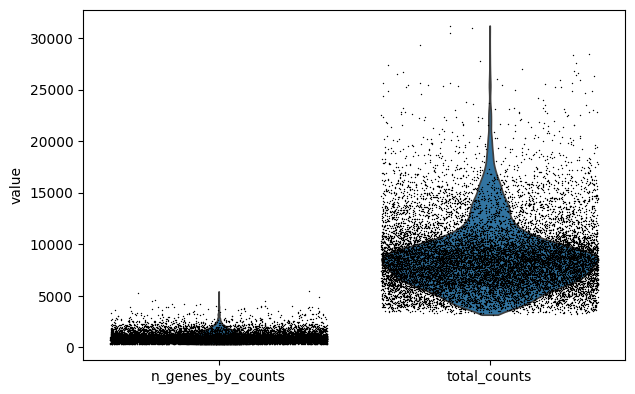

In [ ]:
sc.pl.violin(bone_marrow_adata, ['n_genes_by_counts', 'total_counts'], jitter=0.4)

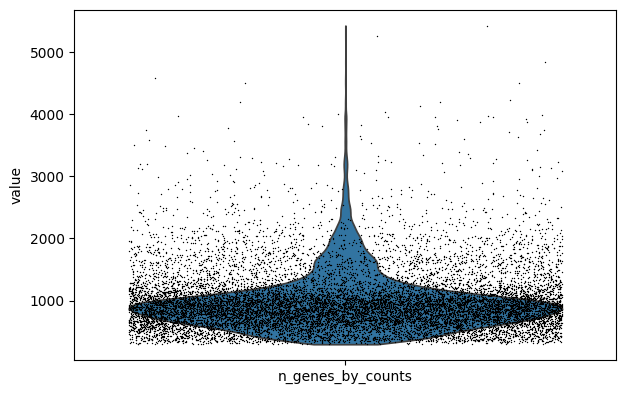

In [ ]:
sc.pl.violin(bone_marrow_adata, ['n_genes_by_counts'], jitter=0.4)

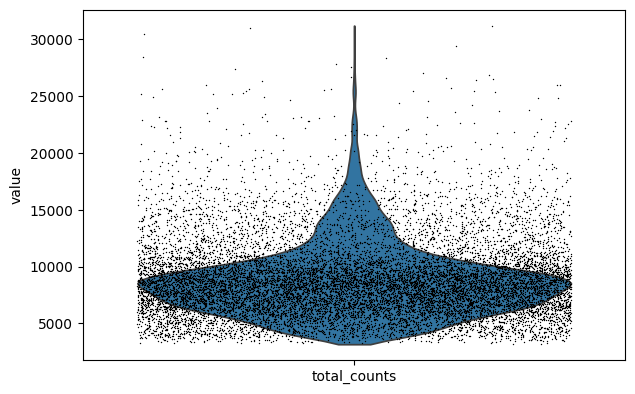

In [ ]:
sc.pl.violin(bone_marrow_adata, ['total_counts'], jitter=0.4)

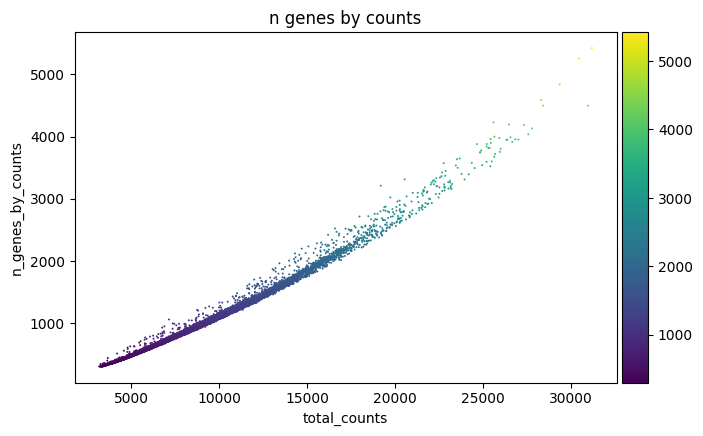

In [ ]:
sc.pl.scatter(bone_marrow_adata, x='total_counts', y='n_genes_by_counts', color='n_genes_by_counts')

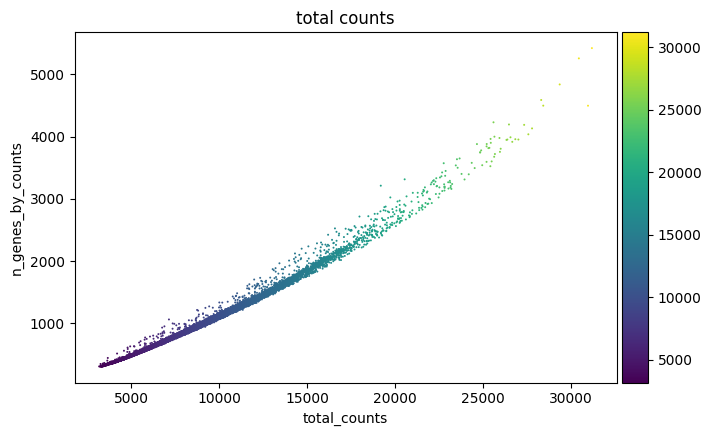

In [ ]:
sc.pl.scatter(bone_marrow_adata, x='total_counts', y='n_genes_by_counts', color='total_counts')

In [ ]:
# There was no need for the filtering step based on the QC outcome

In [ ]:
# Doublet detection

In [ ]:
sc.pp.scrublet(bone_marrow_adata)

### Normalization
Since normalization adjusts for sequencing depth differences between cells, counts in the dataset were scaled so that each cell can the same total expression level.

In [ ]:
# First, save a copy of the data as follows:
bone_marrow_adata.layers["counts"] = bone_marrow_adata.X.copy()

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(bone_marrow_adata)

# Logarithmize the data
sc.pp.log1p(bone_marrow_adata)

In [ ]:
#Feature selection
# Selecting the top 1000 most variable genes
sc.pp.highly_variable_genes(bone_marrow_adata, n_top_genes=1000)

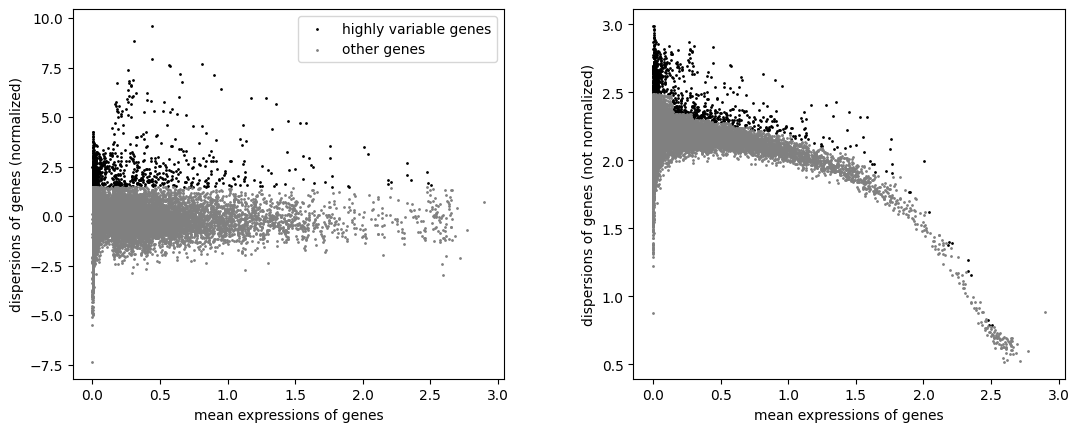

In [ ]:
sc.pl.highly_variable_genes(bone_marrow_adata )
#left is normalized
#right is not

### Dimensionality Reduction (PCA)
**Principal Component Analysis (PCA)** was used to reduce the data complexity and highlight key variation patterns for faster and more robust downstream steps like clustering and visualization .

In [ ]:
sc.tl.pca(bone_marrow_adata)

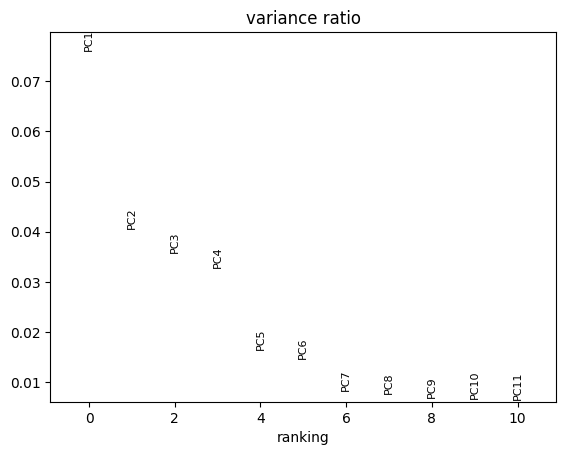

In [ ]:
sc.pl.pca_variance_ratio(bone_marrow_adata, n_pcs=10, log=False)

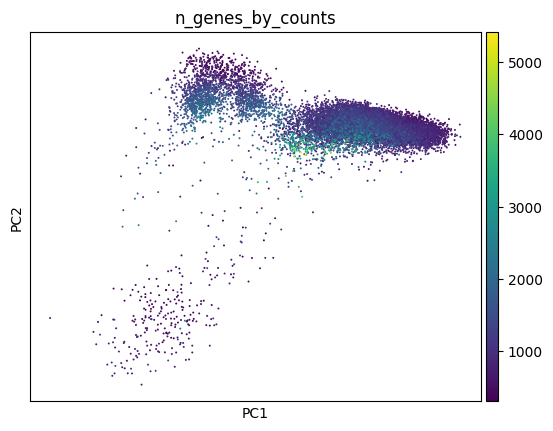

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["n_genes_by_counts"]
)

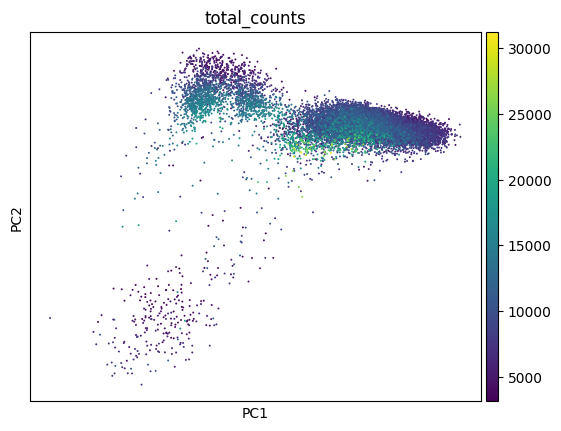

In [ ]:
sc.pl.pca(
    bone_marrow_adata,
    color=["total_counts"]
)

In [ ]:
## Nearest Neighbour
# The PCA representation of the data matrix was used to compute the neighborhood graph of cells, to cluster the PCA components.

In [ ]:
sc.pp.neighbors(bone_marrow_adata)

In [ ]:
sc.tl.umap(bone_marrow_adata)

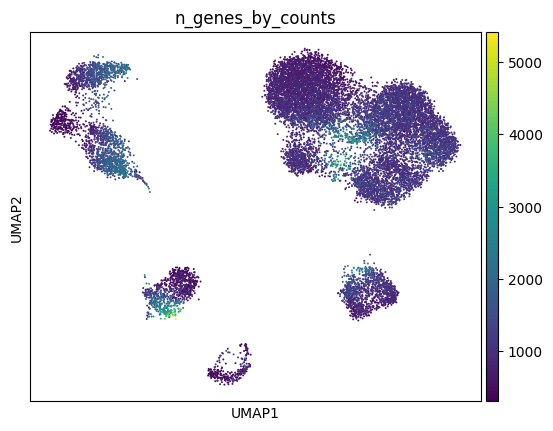

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["n_genes_by_counts"],
    size=8,
)

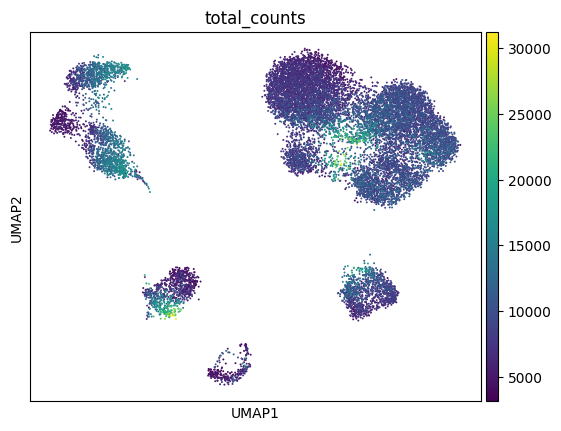

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["total_counts"],
    size=8,
)

In [ ]:
## Clustering by communities.

## Grouping of cells that show similar expression profiles, for cell type detection.

In [ ]:
# Using the igraph implementation and a fixed number of iterations.
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2)

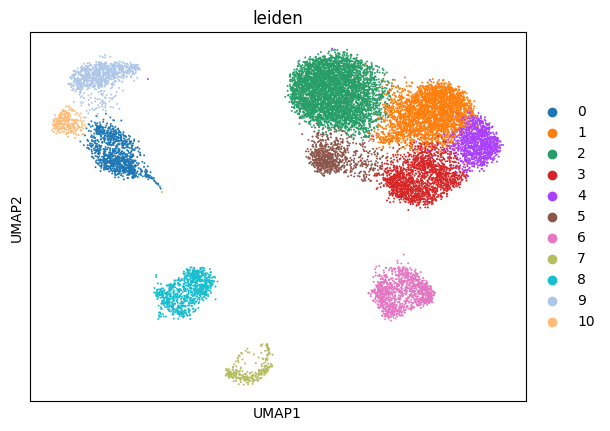

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    size=8,
)

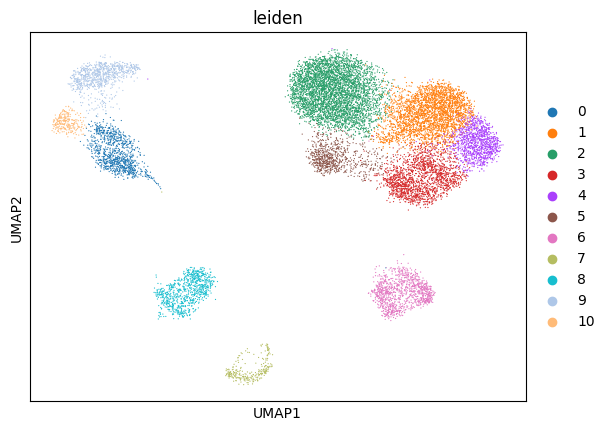

In [ ]:
# Playing around the sizing and spacing
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

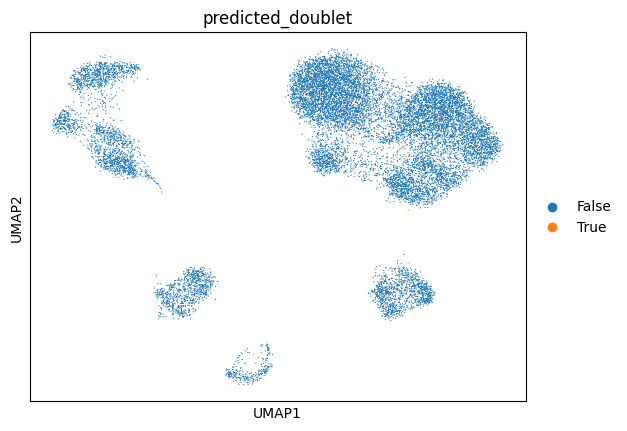

In [ ]:
# Checking for doublets

sc.pl.umap(
    bone_marrow_adata,
    color=[ "predicted_doublet"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

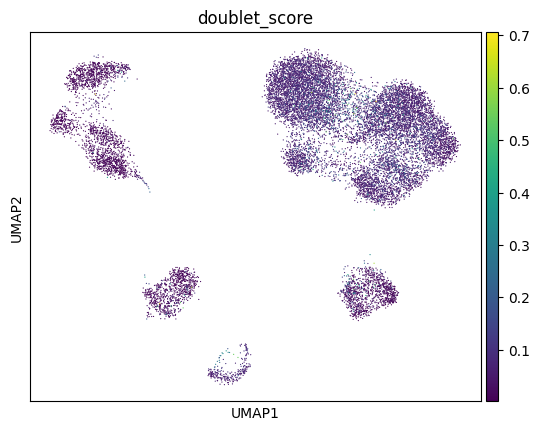

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=[ "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    ncols = 1
)

In [ ]:
# Further reclustering

In [ ]:
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(bone_marrow_adata, flavor="igraph", n_iterations=2, key_added="leiden_res2", resolution=2)

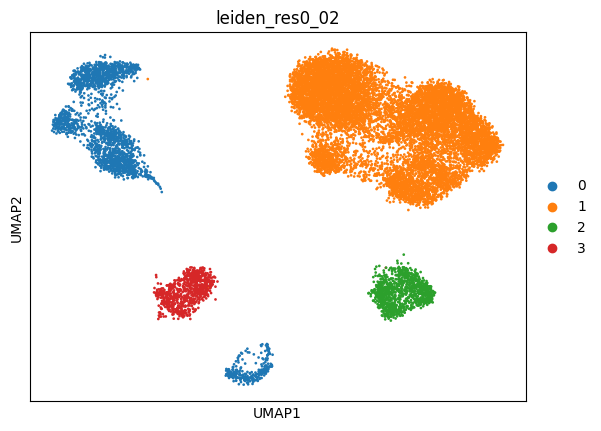

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_02"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1
)

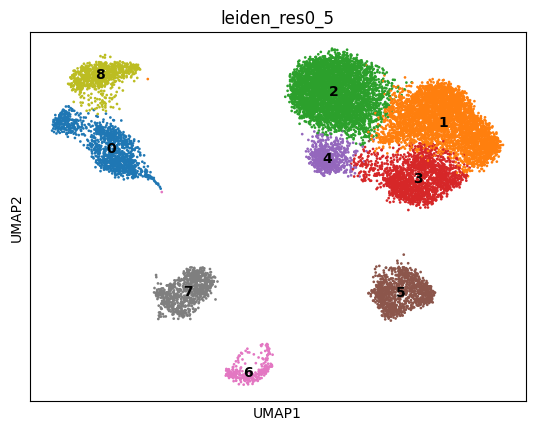

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res0_5"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1,
    legend_loc="on data"
)

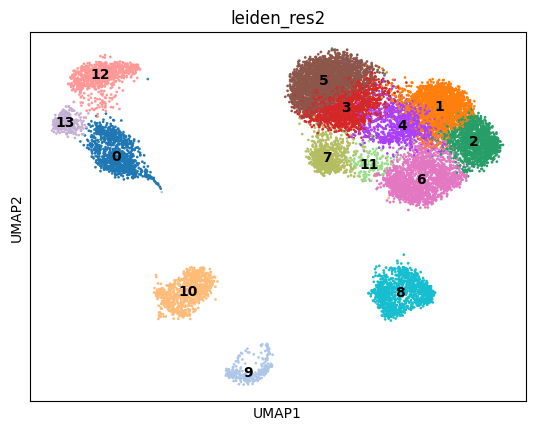

In [ ]:
sc.pl.umap(
    bone_marrow_adata,
    color=["leiden_res2"],
    # increase horizontal space between panels
    wspace=0.5,
    size=15,
    ncols = 1,
    legend_loc="on data"
)

In [ ]:
# Leiden resolution of 0.5 produced relatively sizeable clusters. So, this resolution was used in the downstream analyses.

### Cell Annotation
Assigning biological meaning (e.g., cell type or functional state) to each cluster found after Leiden clustering, using **Decoupler**.

Decoupler is a framework for gene set activity inference. Instead of labeling clusters by single markers, it estimates the activity of predefined pathways, transcription factors, or cell-type signatures from known databases (e.g., MSigDB, PROGENy, DoRothEA).

In practice:

- One provides the normalized expression matrix (adata).

- Loads gene sets representing known biological programs or cell-type signatures.

- Decoupler calculates an activity score per cell or cluster using methods like weighted mean, ULM, or AUCell.

- One interprets those activities to annotate clusters automatically or semi-automatically.

**Data correction**:

The dataset was obtained from CZI (Chan Zuckerberg Institute), and uses ensemble gene ids, contrary to what decoupler expects.

To fix this includes running the following codes before importing decoupler:

In [ ]:
!wget wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'


# This downloads the table of genes directly from ensemble

--2025-12-08 18:45:36--  http://wget/
Resolving wget (wget)... failed: Name or service not known.
wget: unable to resolve host address ‘wget’
--2025-12-08 18:45:36--  http://www.ensembl.org/biomart/martservice?query=%3C?xml%20version=%221.0%22%20encoding=%22UTF-8%22?%3E%3C!DOCTYPE%20Query%3E%3CQuery%20%20virtualSchemaName%20=%20%22default%22%20formatter%20=%20%22CSV%22%20header%20=%20%220%22%20uniqueRows%20=%20%220%22%20count%20=%20%22%22%20datasetConfigVersion%20=%20%220.6%22%20%3E%3CDataset%20name%20=%20%22hsapiens_gene_ensembl%22%20interface%20=%20%22default%22%20%3E%3CAttribute%20name%20=%20%22ensembl_gene_id%22%20/%3E%3CAttribute%20name%20=%20%22external_gene_name%22%20/%3E%3C/Dataset%3E%3C/Query%3E
Resolving www.ensembl.org (www.ensembl.org)... 193.62.193.83
Connecting to www.ensembl.org (www.ensembl.org)|193.62.193.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘result.txt’

result.txt              [        <=>    

In [ ]:
import pandas as pd

ensembl_var = pd.read_csv('/content/result.txt', header = None)

ensembl_var.columns = ['ensembl_gene_id', 'gene_name']

ensembl_var.head(3)

,ensembl_gene_id,gene_name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV


In [ ]:
import decoupler as dc

In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Keep canonical cell type markers alone
#markers = markers[markers["canonical_marker"]]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format because dc only accepts cell_type and genesymbol

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]


markers.head()

,source,target
,,
0,Hepatocytes,A1CF
1,Germ cells,A2APA5
2,Bergmann glia,A2M
3,Mast cells,A3FIN4
4,Mast cells,A4GALT


In [ ]:
# Correct target to ensemble
markers = markers.merge(ensembl_var, left_on="target", right_on="gene_name", how="left")
markers = markers.drop(columns=["target"])

# Remove duplicated entries
markers = markers[~markers.duplicated(["source", "ensembl_gene_id"])]

# Format because dc only accepts cell_type and genesymbol
markers = markers.rename(columns={"source": "source", "ensembl_gene_id": "target"})

markers = markers[["source", "target"]]
markers = markers.dropna()

markers.head()

,source,target
0,Hepatocytes,ENSG00000148584
2,Bergmann glia,ENSG00000175899
4,Mast cells,ENSG00000128274
6,Interneurons,ENSG00000115977
7,Neurons,ENSG00000115977


In [ ]:
# Load the gene expression matrix into dc

dc.mt.ulm(data=bone_marrow_adata,
          net=markers,
          tmin = 3)

In [ ]:
# Retrieve the score for each cell type

score = dc.pp.get_obsm(bone_marrow_adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 14783 × 163
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', '

In [ ]:
# Preview the data
bone_marrow_adata.obsm["score_ulm"].head()

,Acinar cells,Adipocyte progenitor cells,Adipocytes,Adrenergic neurons,Airway goblet cells,Alpha cells,Alveolar macrophages,Anterior pituitary gland cells,Astrocytes,B cells,...,Tanycytes,Taste receptor cells,Thymocytes,Transient cells,Trigeminal neurons,Trophoblast cells,Tuft cells,Undefined placental cells,Urothelial cells,Vascular smooth muscle cells
index,,,,,,,,,,,,,,,,,,,,,
Guo-AAACCTGAGAGCTTCT-2,0.883366,-0.983141,0.463400,-0.592726,-1.026889,0.730972,5.187966,-0.233574,0.244758,1.139676,...,0.544296,0.291316,-0.543441,0.495932,-0.939089,-0.363228,3.113940,-0.784177,-0.784177,-0.513300
Guo-AAACCTGAGAGGTTGC-7,-0.906417,-0.776114,-1.485731,-0.467915,-0.810650,1.469071,-0.060520,0.232815,0.117123,-0.117552,...,0.897830,0.768504,3.848090,-0.965013,-0.441157,-0.965013,-0.202421,-0.619050,-0.619050,-0.405214
Guo-AAACCTGAGATACACA-3,-0.892457,-0.764162,-0.380844,-0.460709,-0.798165,1.460475,-0.066724,-0.892457,1.595653,3.544388,...,0.925009,-0.691168,1.906375,0.178275,0.415761,1.260151,0.851602,-0.609516,-0.609516,-0.398974
Guo-AAACCTGAGCGATTCT-1,-0.922276,-0.789694,-0.510303,-0.476102,-0.824834,0.199226,-0.095330,0.199226,0.724745,3.825061,...,-0.673392,-0.714262,0.929784,-0.981898,0.330917,0.141205,1.709482,-0.629881,-0.629881,-0.412304
Guo-AAACCTGAGTGAAGAG-3,-0.643675,-0.551146,0.030286,-0.332284,-0.575670,-0.643675,0.584350,0.931109,-0.008258,1.962160,...,-0.469977,-0.498500,-0.761742,-0.685285,-0.895366,-0.685285,1.787138,-0.439610,-0.439610,-0.287758


In [ ]:
bone_marrow_adata.obsm["score_ulm"].columns

Index(['Acinar cells', 'Adipocyte progenitor cells', 'Adipocytes',
       'Adrenergic neurons', 'Airway goblet cells', 'Alpha cells',
       'Alveolar macrophages', 'Anterior pituitary gland cells', 'Astrocytes',
       'B cells',
       ...
       'Tanycytes', 'Taste receptor cells', 'Thymocytes', 'Transient cells',
       'Trigeminal neurons', 'Trophoblast cells', 'Tuft cells',
       'Undefined placental cells', 'Urothelial cells',
       'Vascular smooth muscle cells'],
      dtype='object', length=163)

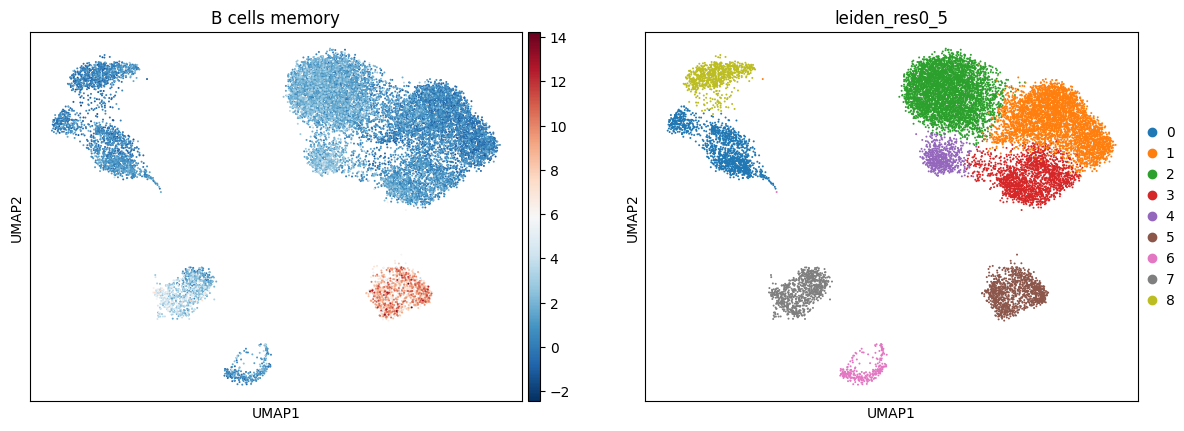

In [ ]:
sc.pl.umap(score, color=["B cells memory", "leiden_res0_5"], cmap="RdBu_r")

In [ ]:
import seaborn as sns

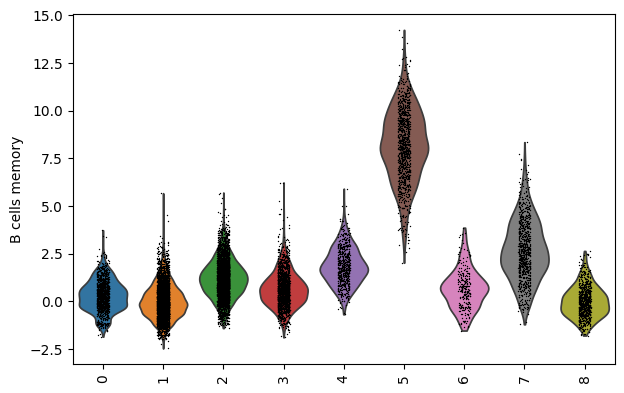

In [ ]:
sc.pl.violin(score, keys=["B cells memory"], groupby="leiden_res0_5", rotation=90)

In [ ]:
#. Identifying what each of the 9 clusters mean

In [ ]:
# Rank genes
bone_marrow_adata_rank = dc.tl.rankby_group(score, groupby="leiden_res0_5", reference="rest", method="t-test_overestim_var")
bone_marrow_adata_rank = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0]
bone_marrow_adata_rank.head()

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,Neutrophils,113.123287,6.402901,0.0,0.0
1,0,rest,Alveolar macrophages,106.999741,4.981299,0.0,0.0
2,0,rest,Monocytes,101.253055,9.876754,0.0,0.0
3,0,rest,Kupffer cells,89.814566,3.643749,0.0,0.0
4,0,rest,Macrophages,89.083095,5.762394,0.0,0.0


In [ ]:
cluster_annotations = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()

/tmp/ipython-input-243225156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_annotations = bone_marrow_adata_rank[bone_marrow_adata_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


In [ ]:
cluster_annotations

{'0': 'Neutrophils',
 '1': 'Gamma delta T cells',
 '2': 'T memory cells',
 '3': 'NK cells',
 '4': 'Nuocytes',
 '5': 'B cells naive',
 '6': 'Platelets',
 '7': 'Plasma cells',
 '8': 'Monocytes'}

In [ ]:
bone_marrow_adata.obs['cell_type'] = bone_marrow_adata.obs['leiden_res0_5'].map(cluster_annotations)


In [ ]:
# Subsetting for multiple genes in the 'source' column
available_genes = set(bone_marrow_adata.var_names)

b_cell_markers = markers[markers['source'].isin(['B cells memory'])]['target']
b_cell_markers = b_cell_markers[b_cell_markers.isin(available_genes)]

nk_cell_markers = markers[markers['source'].isin(['Natural killer T cells'])]['target']
nk_cell_markers = nk_cell_markers[nk_cell_markers.isin(available_genes)]

t_cells_markers = markers[markers['source'].isin(['T cells'])]['target']
t_cells_markers = t_cells_markers[t_cells_markers.isin(available_genes)]

In [ ]:
display(b_cell_markers)

,target
142,ENSG00000042980
331,ENSG00000163568
387,ENSG00000012779
719,ENSG00000112182
724,ENSG00000153064
789,ENSG00000136573
1164,ENSG00000112486
1200,ENSG00000134061
1203,ENSG00000177455
1211,ENSG00000158481


In [ ]:
display(nk_cell_markers)

In [ ]:
display(t_cells_markers)

### Other ways to visualize the cell types

In [ ]:
marker_genes_dict = {
    "B cells": b_cell_markers.head().tolist(),
    "NK cells": nk_cell_markers.head().tolist(),
    "T cells": t_cells_markers.head().tolist()
}

categories: Neutrophils, Gamma delta T cells, T memory cells, etc.
var_group_labels: B cells, NK cells, T cells


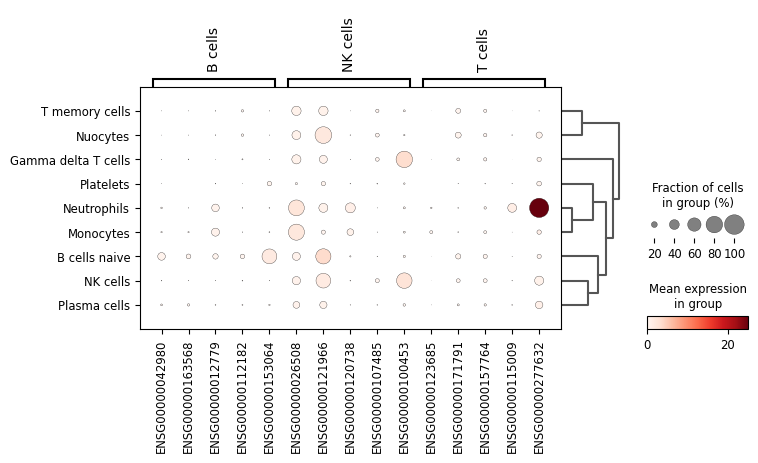

In [ ]:
sc.pl.dotplot(bone_marrow_adata, marker_genes_dict, "cell_type", dendrogram=True)

categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


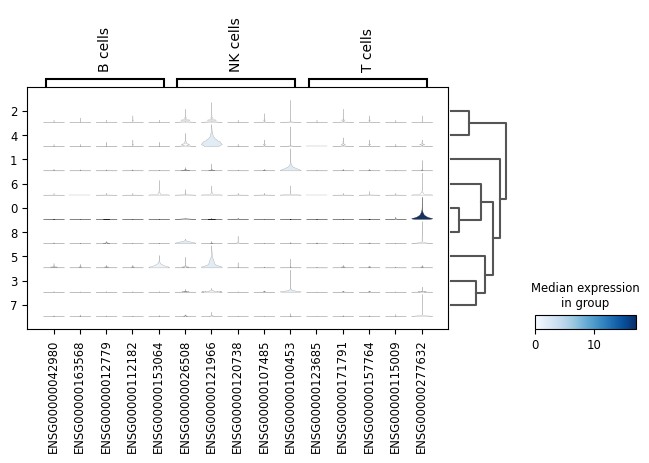

In [ ]:
sc.pl.stacked_violin(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_5",  dendrogram=True
)

categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


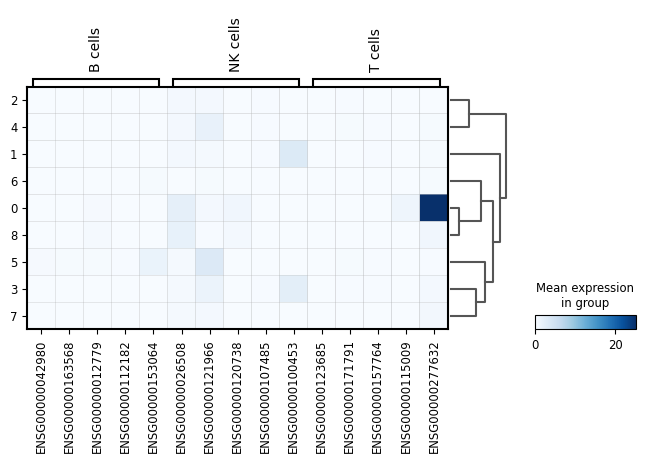

In [ ]:
sc.pl.matrixplot(
    bone_marrow_adata,
    marker_genes_dict,
    "leiden_res0_5",
    dendrogram=True,
    cmap="Blues",
)

categories: 0, 1, 2, etc.
var_group_labels: B cells, NK cells, T cells


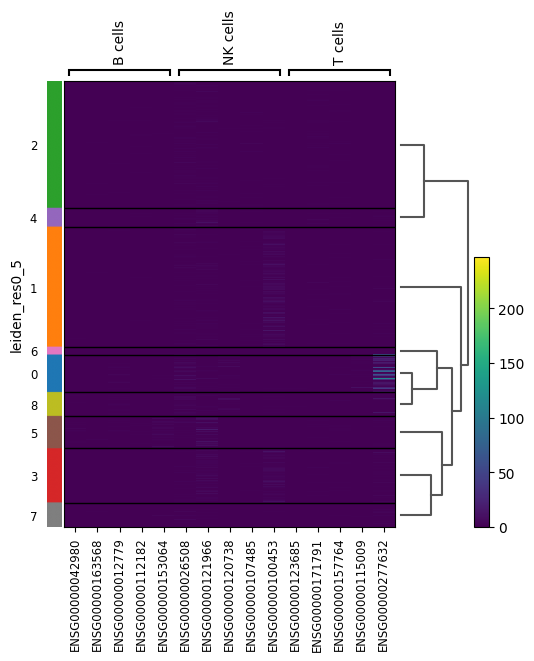

In [ ]:
sc.pl.heatmap(
    bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_5", cmap="viridis", dendrogram=True
)

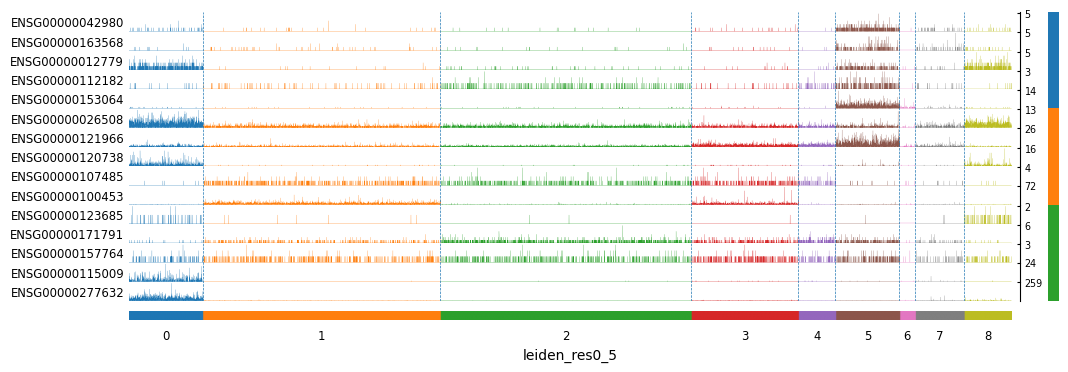

In [ ]:
# Using genome tracks
sc.pl.tracksplot(bone_marrow_adata, marker_genes_dict, groupby="leiden_res0_5", dendrogram=False)

# Biological Interpretation: Questions and Answers

## Q1. What cell types did you identify?
The following cell types were identified, based on each cluster annotation:

- Cluster 0: Neutrophils
- Cluster 1: Gamma delta T cells
- Cluster 2: T memory cells
- Cluster 3: NK cells
- Cluster 4: Nuocytes
- Cluster 5: B cells naive
- Cluster 6: Platelets
- Cluster 7: Plasma cells
- Cluster 8: Monocytes


## Q2. Explain the biological role of each cell type

**1. Neutrophils**: They are produced and stored in large pools within the bone marrow, from where they are rapidly mobilized. In peripheral tissues, they function as first-line innate defenders through phagocytosis, release of reactive oxygen species (ROS), and formation of neutrophil extracellular traps (NETs).

**2. Gamma Delta (γδ) T Cells**: They arise from bone-marrow–derived lymphoid progenitors but develop in the thymus. In peripheral immunity, γδ T cells provide rapid responses at epithelial and mucosal surfaces, recognizing non-peptide antigens in an MHC-independent manner, and contribute early cytokines during infection, tumour or tissue stress.

**3. T Memory Cells**: They are subsets of T cells that home to the bone marrow for long-term maintenance after antigen-driven activation of naïve T cells. In the periphery, they provide accelerated and enhanced immune responses upon re-exposure to previously encountered antigens, a major feature of adaptive immunity.

**4. NK Cells (Natural Killer Cells)**: They originate from bone-marrow progenitors and circulate as cytotoxic innate lymphocytes. In peripheral immunity, they eliminate virus-infected and transformed (tumour) cells and produce IFN-γ to modulate immune responses.

**5. Nuocytes or Group 2 Innate Lymphoid Cells (ILC2s)**: They develop from innate lymphoid progenitors in the bone marrow. In peripheral tissues, they mediate type-2 immunity by producing IL-5 and IL-13, supporting anti-helminth defense, allergic inflammation, and tissue repair.

**6. Naïve B Cells**: Naïve B cells complete their development and B-cell receptor rearrangement in the bone marrow. After maturation, they enter peripheral circulation and localize to secondary lymphoid organs, where they survey for cognate antigen. Upon activation, naïve B cells differentiate into antibody-secreting plasma cells or memory B cells, initiating humoral immune responses.

**7. Platelets**: Platelets are generated by megakaryocytes in the bone marrow. In peripheral immunity, they function not only in haemostasis but also as immune mediators by releasing inflammatory factors and interacting with leukocytes. Their immunomodulatory abilities link coagulation with innate immunity.

**8. Plasma Cells**: Plasma cells represent the terminal differentiation stage of activated B cells. Long-lived plasma cells often home to the bone marrow, where they persist and continuously secrete high-affinity antibodies for long-term serological memory. Short-lived plasma cells in peripheral tissues produce immediate, high-titer antibody responses during acute infection. They are the primary mediators of humoral immunity.

**9. Monocytes**: They are produced from myeloid progenitors in the bone marrow and released into circulation. In peripheral immunity, they migrate into tissues, differentiate into macrophages or dendritic cells, and perform phagocytosis and antigen presentation.

## Q3. Is the tissue source really bone marrow? Justify your answer

It looks like the tissue source is NOT bone marrow for the following reasons:

**Missing bone marrow-specific progenitor populations**: The identified cell types in the clusters include (mature) neutrophils, monocytes, B and T lineages, NKs and platelets but no obvious haematopoietic progenitor or erythroid clusters that are bone marrow-specific.

**Typical peripheral blood frequency distribution of mature immune cells**: The dendogram, for example, shows many mature lymphoid (T memory, gamma delta T cells, NK cells, naive B cells, plasma cells) and myeloid (neutrophils, monocytes) populations at sizes and frequencies consistent with a peripheral blood sample. Bone marrow usually has a different composition, which includes higher proportions of immature myeloid precursors and erythroid cells, and often different relative abundances of mature circulating lymphocytes.

**Presence of platelets with other circulating leukocytes**:
Platelets were identified alongside mature leukocyte types, a pattern expected in whole blood or PBMC preps contaminated with platelets. In bone marrow, platelets are produced by megakaryocytes, hence, one would expect to see megakaryocyte lineage signatures rather than free platelets dominating a cluster.

In conclusion, it is more likely the tissue is a peripheral blood or whole blood sample (or PBMCs with platelet contamination), and not bone marrow, except in any of the following scenarios where bone marrow could masquerade as peripheral blood:

(a) the assay lacked progenitor markers,

(b) the experiment intentionally depleted progenitors, or

(c) there was an annotation error.

## Q4. Based on the relative abundance of cell types, is the patient healthy or infected?
The identified cell-type proportions are most consistent with an active infection or inflammatory state (most likely an acute innate response, classically bacterial) rather than a healthy steady state, due to the following reasons:

The results show that neutrophils have the largest relative abundance (over 90% fraction of cells in a group) and the highest mean or median expression in group, compared to other identified cell types. Such outcome is contrary to what one would expect for a healthy resting peripheral blood profile. An increased neutrophil fraction is therefore strong evidence for an ongoing innate inflammatory response, particularly in an acute bacterial infection, where neutrophilia (increase in the frequency and number of neutrophils) is the dominant signal.

Furthermore, the number of monocytes also seems to be elevated relative to a healthy baseline. Monocytosis (increase in the number of circulating monocytes) commonly accompanies acute infection and inflammation, and can reflect mobilisation of inflammatory monocyte subsets that move to tissues and differentiate to macrophages or dendritic cells (DCs). Hence, neutrophilia and monocytosis strengthens the interpretation of an active inflammatory or infectious process rather than an isolated lymphoid perturbation.

Moreover, the results show a non-trivial NK cell activation states, suggesting a non-antiviral response. Numerically increased NK cells with transcriptional evidence of activation, such as cytotoxic or IFN-γ signatures, would indicate innate antiviral or early anti-infectious activity.

Finally, despite a mix of adaptive immunity (indicated by the presence of lymphoid cells), innate myeloid cells dominated the immune response. Such phenomenon is commonly seen in acute severe infection and systemic inflammation where innate cells expand and lymphocytes marginate, deplete or are redistributed into tissues.